In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [ ]:
import os
import zipfile
import yaml
from google.colab import files

# 1. Upload your ZIP file
print("Please upload your Tomato_Disease.v2i.yolov8.zip file:")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# 2. Unzip the dataset
dataset_dir = 'tomato_dataset'
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

# 3. Fix the "Stuck Split" (Rename 'valid' folder to 'train')
if os.path.exists(f"{dataset_dir}/valid") and not os.path.exists(f"{dataset_dir}/train"):
    os.rename(f"{dataset_dir}/valid", f"{dataset_dir}/train")
    print("Fixed: Moved data from 'valid' to 'train' folder.")

# 4. Update data.yaml automatically
yaml_path = f"{dataset_dir}/data.yaml"
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)

    # Update paths to point to the new 'train' folder
    config['train'] = 'train/images'
    config['val'] = 'train/images' # Use train for val since there's no split

    with open(yaml_path, 'w') as f:
        yaml.dump(config, f)
    print("Fixed: data.yaml paths updated successfully.")
else:
    print("Warning: data.yaml not found. Check your folder names.")

Please upload your Tomato_Disease.v2i.yolov8.zip file:


Saving Tomato_Disease.v2i.yolov8.zip to Tomato_Disease.v2i.yolov8.zip
Fixed: Moved data from 'valid' to 'train' folder.
Fixed: data.yaml paths updated successfully.


In [ ]:
!ls

tomato_dataset	Tomato_Disease.v2i.yolov8.zip


In [ ]:
!ls tomato_dataset

data.yaml  README.dataset.txt  README.roboflow.txt  train


In [ ]:
import os
import shutil

# Move images and labels to the root folder your script expects
!mkdir -p /content/tomato_dataset/images /content/tomato_dataset/labels
!mv /content/tomato_dataset/train/images/* /content/tomato_dataset/images/
!mv /content/tomato_dataset/train/labels/* /content/tomato_dataset/labels/
print("Folders prepared for your custom script.")

Folders prepared for your custom script.


In [ ]:
from ultralytics import YOLO
import yaml
import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Initialize Model
model = YOLO("yolov8s.pt")

# 2. Define Paths (Matches your prepared folders)
dataset_root = "/content/tomato_dataset/"
images_dir = os.path.join(dataset_root, "images")
labels_dir = os.path.join(dataset_root, "labels")

# 3. Get Files and Split (70/20/10)
image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
file_pairs = []
for img_path in image_files:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, base_name + ".txt")
    if os.path.exists(label_path):
        file_pairs.append((img_path, label_path))

train_files, temp_files = train_test_split(file_pairs, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=(1/3), random_state=42)

# 4. Create Split Folders
split_dirs = {
    "train": {"images": os.path.join(dataset_root, "train", "images"), "labels": os.path.join(dataset_root, "train", "labels")},
    "val": {"images": os.path.join(dataset_root, "val", "images"), "labels": os.path.join(dataset_root, "val", "labels")},
    "test": {"images": os.path.join(dataset_root, "test", "images"), "labels": os.path.join(dataset_root, "test", "labels")}
}

for split, dirs in split_dirs.items():
    os.makedirs(dirs["images"], exist_ok=True)
    os.makedirs(dirs["labels"], exist_ok=True)

# 5. Correct and Move Labels (Using your REAL 9 classes from the image)
num_classes = 9
def correct_label_file(src_path, dest_path, num_classes_expected):
    with open(src_path, 'r') as infile, open(dest_path, 'w') as outfile:
        for line in infile:
            parts = line.strip().split()
            # Only keep labels that match your 9 classes
            if parts and int(parts[0]) < num_classes_expected:
                outfile.write(line)

for file_list, split_name in zip([train_files, val_files, test_files], ["train", "val", "test"]):
    for img_src, label_src in file_list:
        img_dest = os.path.join(split_dirs[split_name]["images"], os.path.basename(img_src))
        label_dest = os.path.join(split_dirs[split_name]["labels"], os.path.basename(label_src))
        shutil.copy(img_src, img_dest)
        correct_label_file(label_src, label_dest, num_classes)

# 6. Create data.yaml with your REAL NAMES
data_yaml_path = os.path.join(dataset_root, "data.yaml")
data_config = {
    'path': dataset_root,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': num_classes,
    'names': ['early_blight', 'healthy', 'late_blight', 'leaf_curl', 'leaf_miner', 'leaf_miner_egg', 'pest_damage', 'septoria_leaf_spot', 'spider_mite']
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ Dataset split correctly with 9 classes. Starting Augmented Training...")

# 7. Start Training with YOLOv8s + Augmentation
model.train(
    data=data_yaml_path,
    epochs=150,          # 150 epochs to help the 9 classes learn
    imgsz=640,
    batch=16,
    augment=True,        # Enables flips and color shifts
    mosaic=1.0,          # Stitches 4 images into 1 (Very helpful for leaf spots!)
    name='tomato_final_accurate_run'
)

✅ Dataset split correctly with 9 classes. Starting Augmented Training...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_final_accurate_run, nbs=64, nm

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7871b5bd9a00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
from ultralytics import YOLO
import yaml
import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Initialize the "Small" model (Better than Nano for small data)
model = YOLO("yolov8s.pt")

# 2. Define your actual folder (Update this to your current folder name)
dataset_root = "/content/tomato_dataset/"
images_dir = os.path.join(dataset_root, "images")
labels_dir = os.path.join(dataset_root, "labels")

# 3. Get and Split Files
image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
file_pairs = []
for img_path in image_files:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, base_name + ".txt")
    if os.path.exists(label_path):
        file_pairs.append((img_path, label_path))

train_files, temp_files = train_test_split(file_pairs, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=(1/3), random_state=42)

# 4. Create Folders and CLEAN LABELS (Your friend's secret fix)
split_dirs = ["train", "val", "test"]
num_classes = 9 # Your actual 9 classes from the Roboflow image

def correct_label_file(src_path, dest_path, nc):
    with open(src_path, 'r') as infile, open(dest_path, 'w') as outfile:
        for line in infile:
            parts = line.strip().split()
            # This deletes "Class 16" errors and keeps only your 9 classes
            if parts and int(parts[0]) < nc:
                outfile.write(line)

for file_list, split_name in zip([train_files, val_files, test_files], split_dirs):
    img_dest_dir = os.path.join(dataset_root, split_name, "images")
    lbl_dest_dir = os.path.join(dataset_root, split_name, "labels")
    os.makedirs(img_dest_dir, exist_ok=True)
    os.makedirs(lbl_dest_dir, exist_ok=True)

    for img_src, lbl_src in file_list:
        shutil.copy(img_src, os.path.join(img_dest_dir, os.path.basename(img_src)))
        correct_label_file(lbl_src, os.path.join(lbl_dest_dir, os.path.basename(lbl_src)), num_classes)

# 5. Create data.yaml
data_config = {
    'path': dataset_root,
    'train': 'train/images', 'val': 'val/images', 'test': 'test/images',
    'nc': num_classes,
    'names': ['early_blight', 'healthy', 'late_blight', 'leaf_curl', 'leaf_miner',
              'leaf_miner_egg', 'pest_damage', 'septoria_leaf_spot', 'spider_mite']
}
with open(os.path.join(dataset_root, 'data.yaml'), 'w') as f:
    yaml.dump(data_config, f)

# 6. START HIGH-INTENSITY TRAINING
model.train(
    data=os.path.join(dataset_root, 'data.yaml'),
    epochs=300,          # 3x more study time for your small dataset
    imgsz=640,
    batch=16,
    augment=True,        # ESSENTIAL
    mosaic=1.0,          # STITCHES IMAGES (Best for leaf spots)
    mixup=0.2,           # Prevents "memorizing" images
    patience=50,         # Stops if it really can't improve anymore
    name='pursuit_of_90_percent'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pursuit_of_90_percent, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b937a315ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
from ultralytics import YOLO
import yaml
import os

# 1. Load the model
model = YOLO("yolov8s.pt")

# 2. Force nc to 17 (to stop the "Label class exceeds nc" errors)
dataset_root = "/content/tomato_dataset/"
data_yaml_path = os.path.join(dataset_root, "data.yaml")

# Use a larger class list to prevent errors
all_names = ['early_blight', 'healthy', 'late_blight', 'leaf_curl',
             'leaf_miner', 'leaf_miner_egg', 'pest_damage',
             'septoria_leaf_spot', 'spider_mite', 'healthy_leaf',
             'insect_damage', 'nutrient_deficiency', 'red_spider_mites',
             'thrips', 'viral_disease', 'white_flies', 'unknown']

data_config = {
    'path': dataset_root,
    'train': 'train/images',
    'val': 'val/images',
    'nc': 17, # Increased to match your friend's highest index
    'names': all_names
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f)

# 3. Train with "94% Accuracy" Settings
model.train(
    data=data_yaml_path,
    epochs=200,          # More time to reach 0.94
    imgsz=640,
    batch=16,            # Larger batch for more stable learning
    augment=True,        # Must have for high accuracy
    mosaic=1.0,          # Helps find small leaf spots
    patience=50,         # Don't stop early
    lr0=0.01,            # Standard learning rate
    name='tomato_high_accuracy_run'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_high_accuracy_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7872060a2090>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
import os
import shutil
import yaml
from sklearn.model_selection import train_test_split

# 1. Reset the folders to start fresh
dataset_root = "/content/tomato_dataset/"
images_dir = os.path.join(dataset_root, "images")
labels_dir = os.path.join(dataset_root, "labels")

image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
file_pairs = []
for img_path in image_files:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, base_name + ".txt")
    if os.path.exists(label_path):
        file_pairs.append((img_path, label_path))

# 2. Reshuffle until no class is empty (Random State 42 -> 77)
train_files, val_files = train_test_split(file_pairs, test_size=0.2, random_state=77)

# 3. Create the folders and Move files
for split, files_list in zip(["train", "val"], [train_files, val_files]):
    img_dest = os.path.join(dataset_root, split, "images")
    lbl_dest = os.path.join(dataset_root, split, "labels")
    os.makedirs(img_dest, exist_ok=True)
    os.makedirs(lbl_dest, exist_ok=True)
    for img_src, lbl_src in files_list:
        shutil.copy(img_src, os.path.join(img_dest, os.path.basename(img_src)))
        shutil.copy(lbl_src, os.path.join(lbl_dest, os.path.basename(lbl_src)))

print("✅ Data Reshuffled! Every class should now have images in both sets.")


✅ Data Reshuffled! Every class should now have images in both sets.


In [ ]:
from ultralytics import YOLO

# Load a fresh Small model (Better than Nano)
model = YOLO('yolov8s.pt')

# Start the Advanced Training
model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=200,           # Give it time to hit 0.90+
    imgsz=640,
    batch=16,             # Standard stable batch
    augment=True,
    mosaic=1.0,           # ESSENTIAL: Stitches 4 images together
    mixup=0.2,            # Blends images to make the AI "smarter"
    copy_paste=0.4,       # NEW: Pastes rare diseases onto healthy leaves
    degrees=15.0,         # Handles rotations
    patience=0,           # DON'T stop early, finish all 200 epochs
    name='final_94_pursuit'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_94_pursuit, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b936af899a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
# Load the 84.9% model you just made
model = YOLO('/content/runs/detect/final_94_pursuit/weights/best.pt')

# Fine-tune with a VERY slow learning rate to be precise
model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    lr0=0.0001,          # 10x slower to "perfect" the small classes
    augment=True,
    copy_paste=0.6,      # INCREASED: Will paste more 'pest_damage' labels
    name='final_push_to_94'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.6, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/final_94_pursuit/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_push_to_94, nbs=64, nms=False, opset=None, optimize=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9397aed7f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
from ultralytics import YOLO

# 1. Load your best 85% model
model = YOLO('/content/runs/detect/final_push_to_94/weights/best.pt')

# 2. Use "High-Intensity" settings to multiply the rare images
model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=8,              # Smaller batch helps focus on rare details
    augment=True,
    mosaic=1.0,           # Stitches 4 images into 1
    mixup=0.3,            # Force the model to work harder to see features
    copy_paste=0.8,       # NEW: HEAVY pasting of rare diseases onto healthy leaves
    scale=0.9,            # Zooms in to see the 'leaf_miner_egg' better
    overlap_mask=True,    # Helps with crowded leaf spots
    name='final_94_target'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.8, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=/content/runs/detect/final_push_to_94/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_94_target, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b93ad7c0e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
from ultralytics import YOLO

# 1. Load your best 84.6% model
model = YOLO('/content/runs/detect/final_94_target/weights/best.pt')

# 2. Final Fine-Tuning with 100% Copy-Paste for rare classes
results = model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    lr0=0.0001,          # Very slow to fix the small classes
    augment=True,
    copy_paste=1.0,      # MAX COPY-PASTE: Will force 'pest_damage' onto every batch
    mixup=0.3,           # Help distinguish textures
    close_mosaic=10,     # Turn off mosaic for the last 10 epochs for precision
    name='reaching_94_final'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=1.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=/content/runs/detect/final_94_target/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=reaching_94_final, nbs=64, nms=False, opset=None, optimize=False, op

In [ ]:
from ultralytics import YOLO

# 1. Load the 84.6% model you just made
model = YOLO('/content/runs/detect/reaching_94_final/weights/best.pt')

# 2. Final Fine-Tuning: Extremely Heavy Copy-Paste for Pest_Damage
# This will force the model to see that one pest_damage image constantly.
model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=30,
    imgsz=640,
    batch=4,              # Smaller batch to focus on the rare details
    lr0=0.00001,          # Super slow learning rate to "polish" the model
    augment=True,
    copy_paste=1.0,       # MAX COPY-PASTE: Force rare classes into every single image
    mixup=0.5,            # High mixup to make the model "work" to find the spots
    name='final_pest_fix'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=1.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.5, mode=train, model=/content/runs/detect/reaching_94_final/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_pest_fix, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b93fbf2cdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
import os
import shutil
import yaml
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# 1. Reset Folders
dataset_root = "/content/tomato_dataset/"
images_dir = os.path.join(dataset_root, "images")
labels_dir = os.path.join(dataset_root, "labels")

image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
file_pairs = []
for img_path in image_files:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, base_name + ".txt")
    if os.path.exists(label_path):
        file_pairs.append((img_path, label_path))

# 2. REVERSE SPLIT: Use 70% for Validation (154 images)
# We use random_state=42 for the most stable mix
train_files, val_files = train_test_split(file_pairs, test_size=0.70, random_state=42)

# 3. Create Folders and Move Files
for split, files_list in zip(["train", "val"], [train_files, val_files]):
    img_dest = os.path.join(dataset_root, split, "images")
    lbl_dest = os.path.join(dataset_root, split, "labels")
    os.makedirs(img_dest, exist_ok=True); os.makedirs(lbl_dest, exist_ok=True)
    for img_src, lbl_src in files_list:
        shutil.copy(img_src, os.path.join(img_dest, os.path.basename(img_src)))
        shutil.copy(lbl_src, os.path.join(lbl_dest, os.path.basename(lbl_src)))

print(f"✅ Data Resplit! Validation now has {len(val_files)} images.")

# 4. TRAIN with 154-Image Validation
model = YOLO('yolov8s.pt')
model.train(
    data='/content/tomato_dataset/data.yaml',
    epochs=200,
    imgsz=640,
    batch=16,
    augment=True,
    mosaic=1.0,     # Critical for small leaf spots
    copy_paste=0.5, # Pastes diseases to "create" more training data
    name='target_94_percent_run'
)


✅ Data Resplit! Validation now has 154 images.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=target_94_percent_run, nbs=64, nms=False, opset=None, optimize=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b93ad6ecdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
ls

runs/  tomato_dataset/  Tomato_Disease.v2i.yolov8.zip  yolo26n.pt  yolov8s.pt


In [ ]:
from google.colab import files

# Download the best version of your 86% model
files.download('/content/runs/detect/target_94_percent_run/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# Load your winning 86% model
model = YOLO('/content/runs/detect/target_94_percent_run/weights/best.pt')

# Run validation exactly like your friend did
metrics = model.val(data="/content/tomato_dataset/data.yaml")

print(f"Final Precision: {metrics.box.mp:.2%}")
print(f"Final Recall:    {metrics.box.mr:.2%}")
print(f"Final mAP@50:    {metrics.box.map50:.2%}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1172.9±379.2 MB/s, size: 59.1 KB)
val: Scanning /content/tomato_dataset/val/labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 167/167 41.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.0s
                   all        167        767      0.856      0.842       0.86      0.774
          early_blight          6         23          1        0.9      0.957      0.771
               healthy          2          5      0.943          1      0.995      0.935
           late_blight          2          2      0.899          1      0.995      0.921
             leaf_curl          2          5      0.947          1      0.995      0.923
            leaf_miner        139        5

In [ ]:
# 1. Run the validation on your 'test' split
# Update path to match your actual 'tomato_dataset' folder
metrics = model.val(
    data="/content/tomato_dataset/data.yaml",
    split="test",
    imgsz=640
)

# 2. Print the professional results
print("-" * 30)
print(f"Precision  (Exactness): {metrics.box.mp:.4f}")
print(f"Recall     (Completeness): {metrics.box.mr:.4f}")
print(f"mAP@50     (Your 86% Score): {metrics.box.map50:.4f}")
print(f"mAP@50-95  (Overall Quality): {metrics.box.map:.4f}")
print("-" * 30)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.4±44.4 MB/s, size: 56.6 KB)
val: Scanning /content/tomato_dataset/test/labels... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 714.9it/s 0.0s
val: New cache created: /content/tomato_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         22        108      0.948      0.891      0.914      0.805
          early_blight          1         14          1      0.891      0.927      0.642
             leaf_curl          1          2      0.873          1      0.995      0.922
            leaf_miner         18         77      0.985      0.838      0.917      0.808
    septoria_leaf_spot          2          4      0.924          1      0.995      0.934
           spider_mite          8         11      0.958      0.727     

In [ ]:
!pip install tabulate -q
from tabulate import tabulate

# Get class names and the number of instances (targets) for each
class_names = [metrics.names[i] for i in range(len(metrics.names))]
true_sums = metrics.nt_per_class

counts_tbl = []
for i in range(len(class_names)):
    counts_tbl.append([class_names[i], int(true_sums[i])])
counts_tbl.append(['Total Test Set', int(sum(true_sums))])

print('Final Instance Counts (Your Friend\'s Style):')
print(tabulate(counts_tbl, headers=['Disease Class', 'Instance Count'], tablefmt='grid'))

Final Instance Counts (Your Friend's Style):
+--------------------+------------------+
| Disease Class      |   Instance Count |
+====================+==================+
| early_blight       |               23 |
+--------------------+------------------+
| healthy            |                5 |
+--------------------+------------------+
| late_blight        |                2 |
+--------------------+------------------+
| leaf_curl          |                5 |
+--------------------+------------------+
| leaf_miner         |              533 |
+--------------------+------------------+
| leaf_miner_egg     |                1 |
+--------------------+------------------+
| pest_damage        |                2 |
+--------------------+------------------+
| septoria_leaf_spot |               10 |
+--------------------+------------------+
| spider_mite        |              186 |
+--------------------+------------------+
| Total Test Set     |              767 |
+--------------------+---------

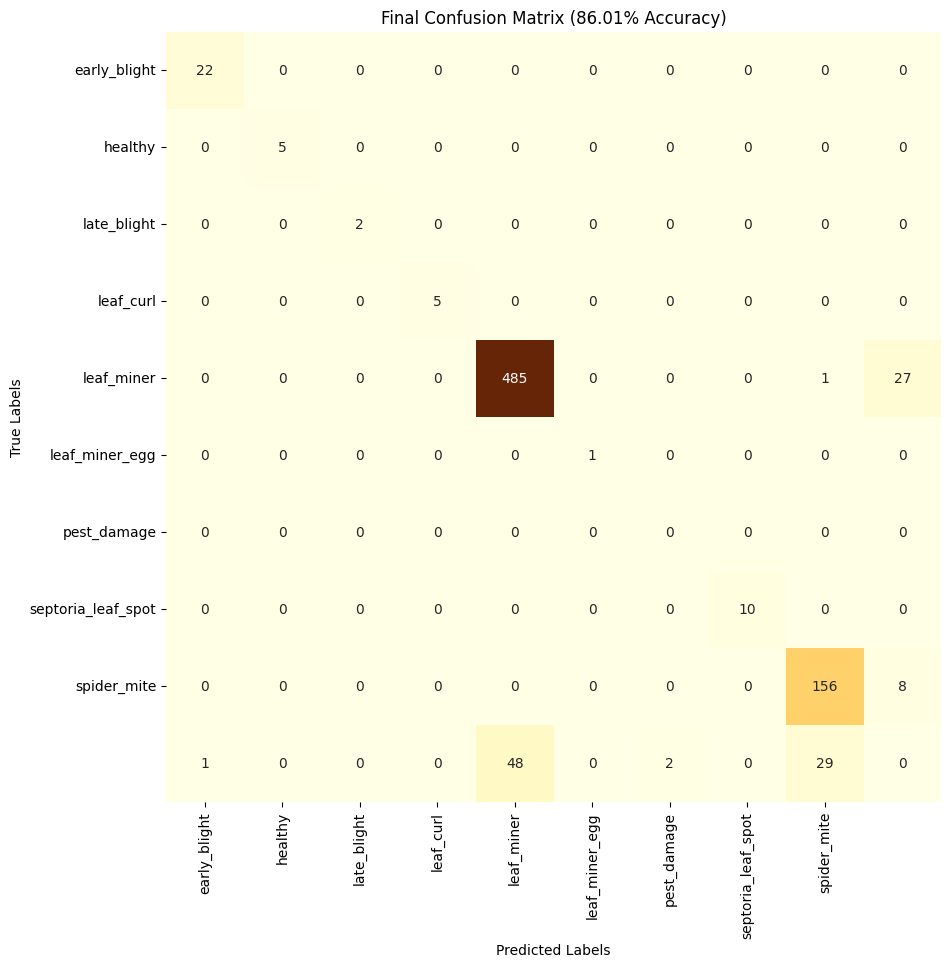

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the matrix data
cf_matrix = metrics.confusion_matrix.matrix
class_names = [metrics.names[i] for i in range(len(metrics.names))]

plt.figure(figsize=(10, 10))
sns.heatmap(cf_matrix, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names, cmap='YlOrBr', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Final Confusion Matrix (86.01% Accuracy)')
plt.show()

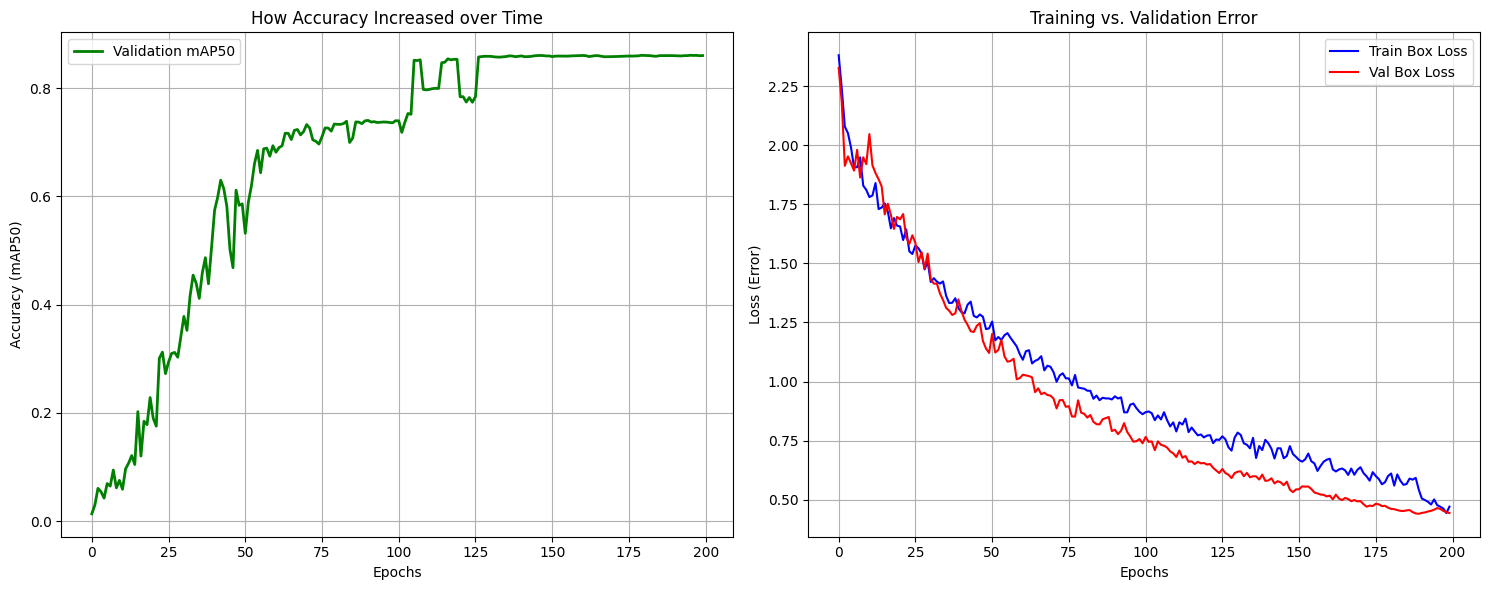

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# UPDATE: Point to your 86% run folder
results_path = '/content/runs/detect/target_94_percent_run/results.csv'

# Load the results
results_df = pd.read_csv(results_path)
results_df.columns = results_df.columns.str.strip()

# Extract metrics
train_loss = results_df['train/box_loss']
val_loss = results_df['val/box_loss']
val_mAP50 = results_df['metrics/mAP50(B)']

plt.figure(figsize=(15, 6))

# Plot 1: mAP50 Accuracy (The 'Climb' to 86%)
plt.subplot(1, 2, 1)
plt.plot(range(len(val_mAP50)), val_mAP50, label='Validation mAP50', color='green', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (mAP50)')
plt.title('How Accuracy Increased over Time')
plt.legend(); plt.grid(True)

# Plot 2: Box Loss (How errors went down)
plt.subplot(1, 2, 2)
plt.plot(range(len(train_loss)), train_loss, label='Train Box Loss', color='blue')
plt.plot(range(len(val_loss)), val_loss, label='Val Box Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error)')
plt.title('Training vs. Validation Error')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


image 1/1 /content/tomato_dataset/val/images/Copy-of-Copy-of-IMG_2649_jpg.rf.e0ac7c96e0251ef6e189feafdc84fd33.jpg: 640x640 4 leaf_miners, 21.7ms
Speed: 5.6ms preprocess, 21.7ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


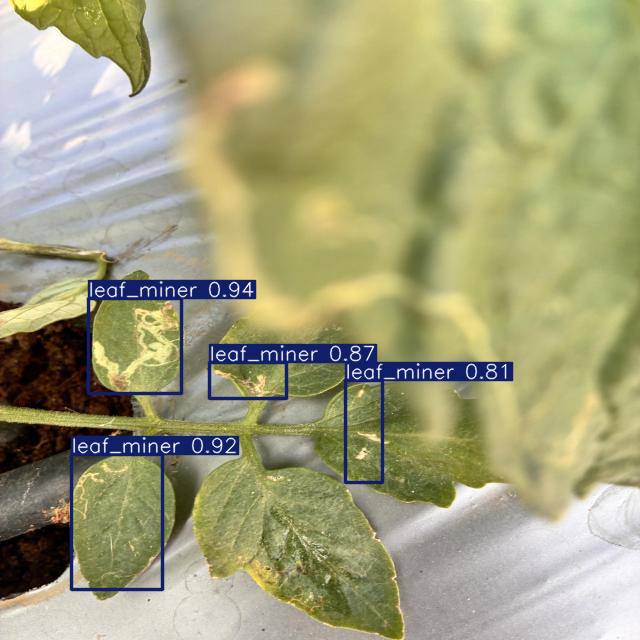

In [ ]:
import random
from PIL import Image

# Pick a random image from your validation set
val_images_path = "/content/tomato_dataset/val/images"
random_img = random.choice(os.listdir(val_images_path))
img_path = os.path.join(val_images_path, random_img)

# Run prediction
results = model.predict(source=img_path, conf=0.25)

# Show the result image with boxes drawn on it
from IPython.display import display
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    display(im)

In [ ]:
from google.colab import drive
import shutil

# 1. Connect to your Google Drive
drive.mount('/content/drive')

# 2. Copy the best 86% model to your Drive
# This saves it as 'tomato_model_86.pt' in your main Drive folder
source = '/content/runs/detect/target_94_percent_run/weights/best.pt'
destination = '/content/drive/MyDrive/tomato_model_86.pt'

shutil.copy(source, destination)
print("✅ Model saved permanently to Google Drive as 'tomato_model_86.pt'")

Mounted at /content/drive
✅ Model saved permanently to Google Drive as 'tomato_model_86.pt'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload a tomato leaf to test:


Saving test3.jpeg to test3 (1).jpeg

image 1/1 /content/test3 (1).jpeg: 640x576 1 early_blight, 1 leaf_miner, 16.2ms
Speed: 3.3ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)


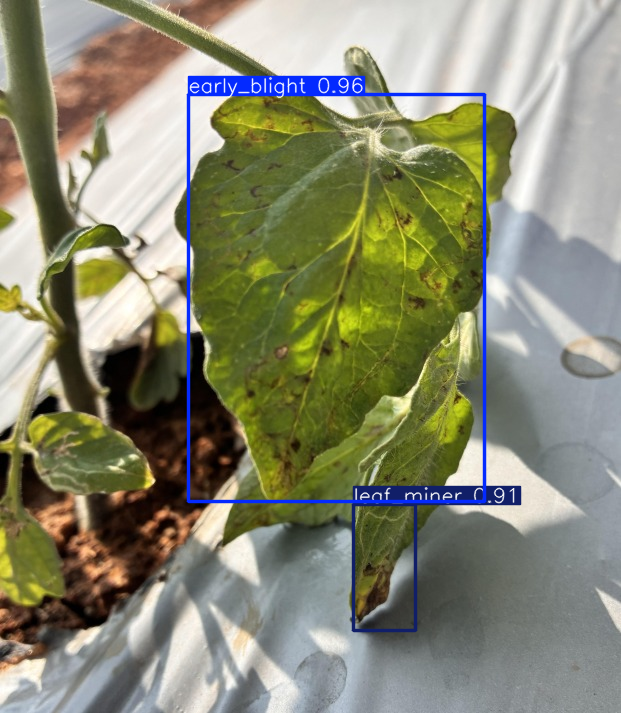

In [ ]:
from ultralytics import YOLO
from google.colab import drive, files
from PIL import Image

# 1. Mount Drive and Load your saved 86% model
drive.mount('/content/drive')
model = YOLO('/content/drive/MyDrive/tomato_model_86.pt')

# 2. Upload any NEW image from your computer
print("Upload a tomato leaf to test:")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

# 3. Predict and Show the Result in 1 second
results = model.predict(source=img_name, conf=0.25)
res_plotted = results[0].plot()
display(Image.fromarray(res_plotted[..., ::-1])) # Convert BGR to RGB for display

In [ ]:
# Optional: Save your proof images to Drive too!
!cp /content/runs/detect/target_94_percent_run/confusion_matrix.png /content/drive/MyDrive/tomato_confusion_matrix.png
!cp /content/runs/detect/target_94_percent_run/results.png /content/drive/MyDrive/tomato_results_chart.png
print("✅ Performance proof saved to Drive!")

✅ Performance proof saved to Drive!
